Импортируем необходимые библиотеки

In [3]:
import pandas as pd
import numpy as np
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import math
import os

In [4]:
print(sqlite3.sqlite_version)

3.53.1


Создаем базу данных SQLite3, для удобства создания витрин данных.

В процессе создания базы данных делаем явное преобразование типов. Некоторые столбцы имеют неподходящие типы.

In [5]:
db_path = 'yammer/yammer.db'
conn = sqlite3.connect(db_path)

data_dir = 'yammer'

files = {
    'emails.csv': {
        'table_name': 'emails',
        'dtype': {
            'user_id': 'Int64',
            'user_type': 'Int64'
        }
	},
    'events.csv': {
        'table_name': 'events',
        'dtype': {
			'user_id': 'Int64',
			'user_type': 'Int64'
		}
    },
    'experiments.csv': {
        'table_name': 'experiments',
        'dtype': {
			'user_id': 'Int64',
			'user_type': 'Int64'
		}
    },
    'users.csv': {
        'table_name': 'users',
        'dtype': {
			'user_id': 'Int64',
			'company_id': 'Int64'
		}
    }
}

for file_name, config in files.items():
    file_path = os.path.join(data_dir, file_name)
    df = pd.read_csv(file_path, dtype=config['dtype'],)
    df.to_sql(config['table_name'], conn, if_exists='replace', index=False)

Подключаемся к созданной базе данных. 

Убедимся что все таблицы присутствуют. 

In [6]:
tables = pd.read_sql_query("""
    SELECT name
    FROM sqlite_master
    WHERE type = 'table';
""", conn)

tables

,name
0,emails
1,events
2,experiments
3,users


Посчитаем количество строк в каждой из таблиц

In [7]:
results = []
for table_name in tables['name']:
    query = f"SELECT COUNT(*) AS row_count FROM {table_name};"
    count = pd.read_sql_query(query, conn)['row_count'][0]
    results.append({'table_name': table_name, 'row_count': count})

pd.DataFrame(results)

,table_name,row_count
0,emails,90389
1,events,340832
2,experiments,2595
3,users,19066


Типы данных в таблице emails.

In [8]:
pd.read_sql_query("""
PRAGMA table_info('emails');
""", conn)

,cid,name,type,notnull,dflt_value,pk
0,0,user_id,INTEGER,0,None,0
1,1,occurred_at,TEXT,0,None,0
2,2,action,TEXT,0,None,0
3,3,user_type,INTEGER,0,None,0


Типы данных в таблице events.

In [9]:
pd.read_sql_query("""
PRAGMA table_info('events');
""", conn)

,cid,name,type,notnull,dflt_value,pk
0,0,user_id,INTEGER,0,None,0
1,1,occurred_at,TEXT,0,None,0
2,2,event_type,TEXT,0,None,0
3,3,event_name,TEXT,0,None,0
4,4,location,TEXT,0,None,0
5,5,device,TEXT,0,None,0
6,6,user_type,INTEGER,0,None,0


Типы данных в таблице experiments.

In [10]:
pd.read_sql_query("""
PRAGMA table_info('experiments');
""", conn)

,cid,name,type,notnull,dflt_value,pk
0,0,user_id,INTEGER,0,None,0
1,1,occurred_at,TEXT,0,None,0
2,2,experiment,TEXT,0,None,0
3,3,experiment_group,TEXT,0,None,0
4,4,location,TEXT,0,None,0
5,5,device,TEXT,0,None,0
6,6,user_type,INTEGER,0,None,0


Типы данных в таблице users.

In [11]:
pd.read_sql_query("""
PRAGMA table_info('users');
""", conn)

,cid,name,type,notnull,dflt_value,pk
0,0,user_id,INTEGER,0,None,0
1,1,created_at,TEXT,0,None,0
2,2,company_id,INTEGER,0,None,0
3,3,language,TEXT,0,None,0
4,4,activated_at,TEXT,0,None,0
5,5,state,TEXT,0,None,0


Типы данных соответсвуют ожидаемым.

Считаем разницу между числом всех юзеров и уникальных юзеров чтобы убедится что они уникальны.

In [12]:
pd.read_sql_query("""
    SELECT
        COUNT(*) AS total_users,
        COUNT(DISTINCT user_id) AS unique_users,
        COUNT(*) - COUNT(DISTINCT user_id) AS duplicate_users
    FROM users;
""", conn)

,total_users,unique_users,duplicate_users
0,19066,19066,0


Определяем временной интервал в котором создавались акканунты юзеров.

In [13]:
pd.read_sql_query(
"""
SELECT
    MIN(created_at) AS min_date,
    MAX(created_at) AS max_date,
    timediff(MAX(created_at), MIN(created_at)) AS period,
    JULIANDAY(MAX(created_at)) - JULIANDAY(MIN(created_at)) AS period_days
FROM users;
""", conn)

,min_date,max_date,period,period_days
0,2013-01-01 04:38:30,2014-08-31 20:40:32,+0001-07-30 16:02:02.000,607.668079


Определяем временной интервал в котором активировались аккаунты юзеров.

In [14]:
pd.read_sql_query(
"""
SELECT
	MIN(activated_at) as min_date,
	MAX(activated_at) as max_date,
    timediff(MAX(activated_at), MIN(activated_at)) AS period,
    JULIANDAY(MAX(activated_at)) - JULIANDAY(MIN(activated_at)) AS period_days
FROM users;
""", conn)

,min_date,max_date,period,period_days
0,2013-01-01 04:40:10,2014-08-31 20:22:54,+0001-07-30 15:42:44.000,607.654676


Считаем количество пропусков в датах активации.

In [15]:
pd.read_sql_query(
"""
SELECT 
    ROUND((COUNT(*) FILTER (WHERE activated_at IS NULL) * 100.0 / COUNT(*)), 2) AS pct_null
FROM users;
""", conn)

,pct_null
0,50.8


51.8 % пропущенных значений.

Распределение юзеров по языкам.

In [16]:
pd.read_sql_query(
"""
SELECT 
	language,
    COUNT(*) AS users_cnt,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM users), 2) AS users_pct
FROM users
GROUP BY language
ORDER BY users_pct DESC;
""", conn)

,language,users_cnt,users_pct
0,english,9585,50.27
1,spanish,1771,9.29
2,french,1522,7.98
3,japanese,1324,6.94
4,german,1067,5.60
5,arabic,768,4.03
6,chinese,685,3.59
7,indian,583,3.06
8,russian,561,2.94
9,portugese,510,2.67


Распределение юзеров по статусам.

In [17]:
pd.read_sql_query(
"""
SELECT 
	state,
    COUNT(*) AS users_cnt,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM users), 2) AS users_pct
FROM users
GROUP BY state
ORDER BY users_pct DESC;
""", conn)

,state,users_cnt,users_pct
0,pending,9685,50.8
1,active,9381,49.2


In [18]:
new_users = pd.read_sql_query(
"""
SELECT
	DATE(created_at) AS created_date,
	COUNT(*) new_users_cnt
FROM users 
GROUP BY created_date
ORDER BY created_date;
""", conn)

new_users

,created_date,new_users_cnt
0,2013-01-01,13
1,2013-01-02,11
2,2013-01-03,14
3,2013-01-04,11
4,2013-01-05,3
...,...,...
603,2014-08-27,90
604,2014-08-28,95
605,2014-08-29,97
606,2014-08-30,26


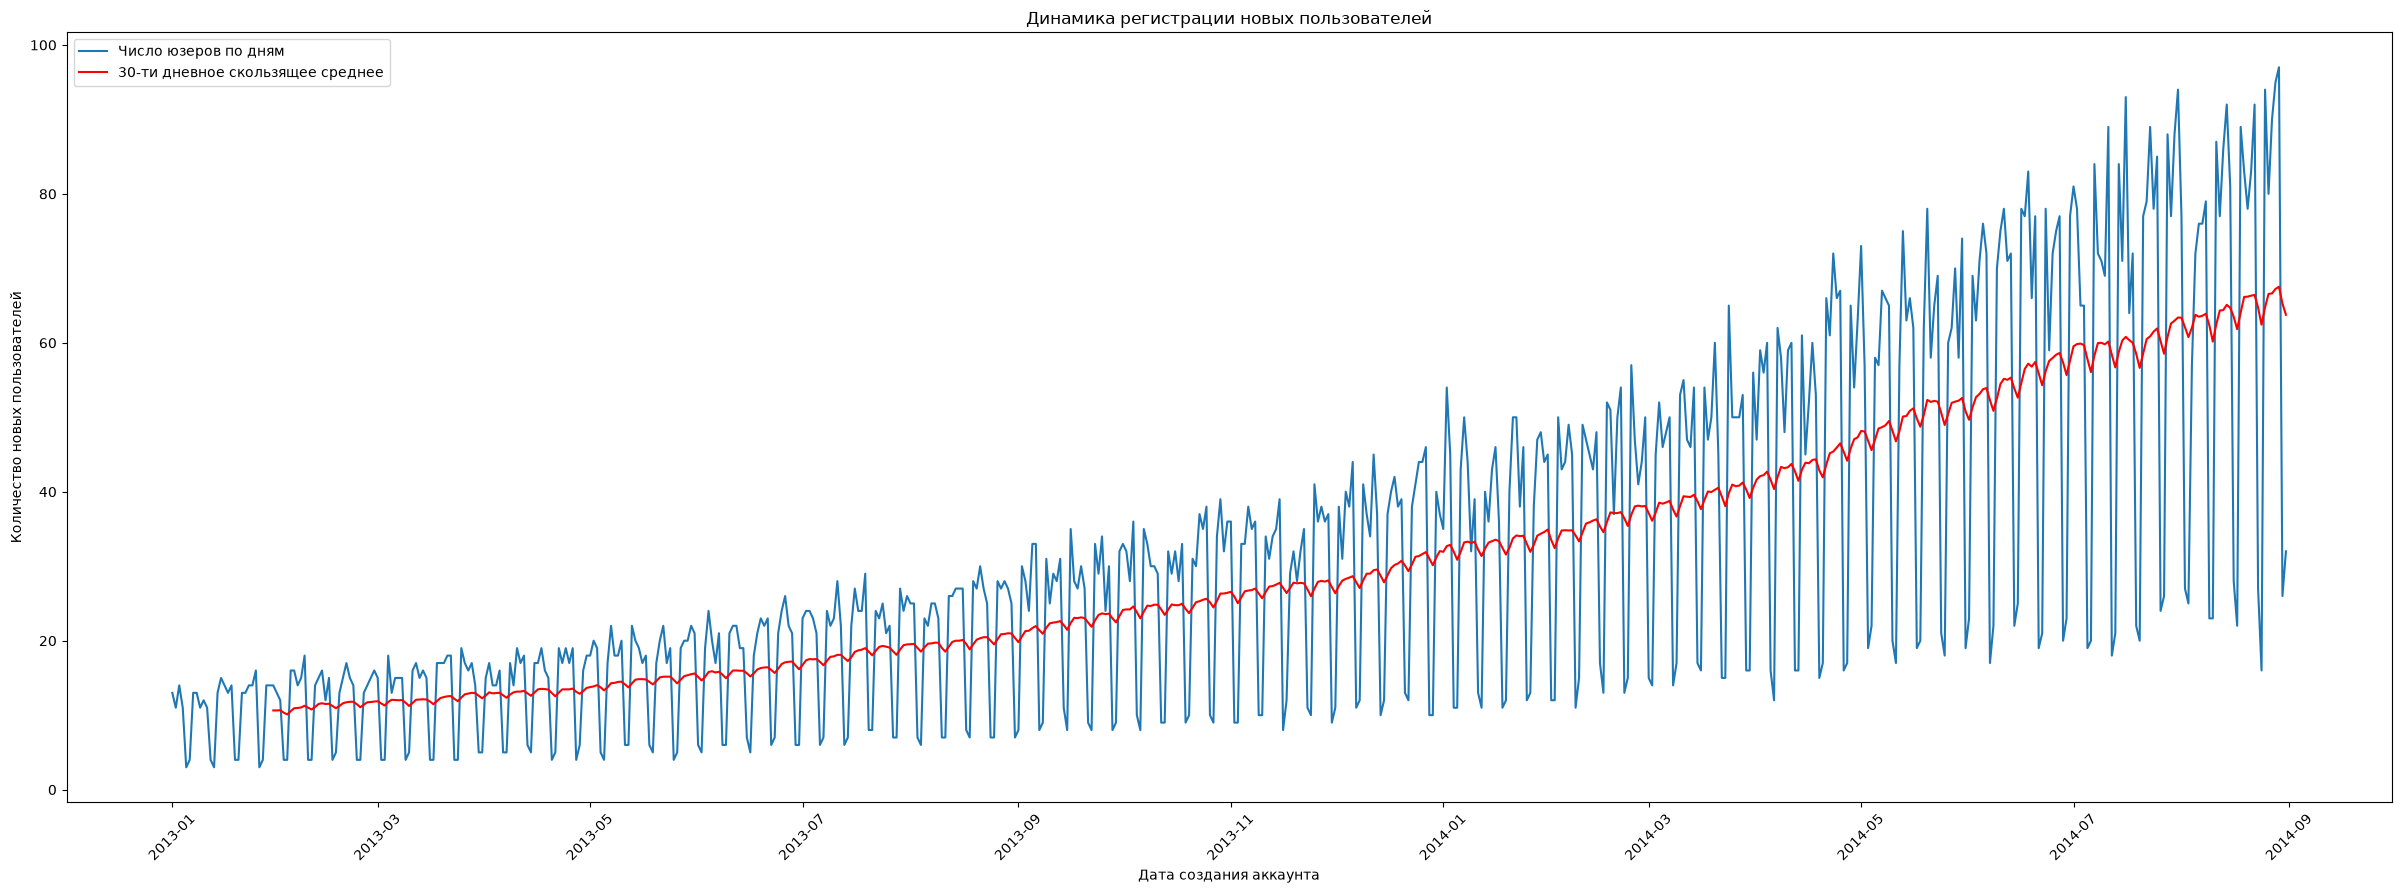

In [19]:
plt.figure(figsize=(30, 10))

new_users['created_date'] = pd.to_datetime(new_users['created_date'])

new_users['rolling_30d'] = new_users['new_users_cnt'].rolling(window=30).mean()

plt.plot(
    new_users['created_date'],
    new_users['new_users_cnt'],
    label='Число юзеров по дням'
)

plt.plot(
    new_users['created_date'],
    new_users['rolling_30d'],
    label='30-ти дневное скользящее среднее',
    color='red'
)


plt.title('Динамика регистрации новых пользователей')
plt.xlabel('Дата создания аккаунта')
plt.ylabel('Количество новых пользователей')
plt.xticks(rotation=45)
plt.legend()
plt.show()

На графике динамики числа пользователей видим сезонные изменения и общий тренд.

Посчитаем размеры компаний.

In [20]:
pd.read_sql_query(
"""
SELECT
    company_id,
    COUNT(*) AS users_cnt,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM users), 2) AS company_pct
FROM users
GROUP BY company_id
ORDER BY users_cnt DESC;
""", conn)

,company_id,users_cnt,company_pct
0,1,1036,5.43
1,2,477,2.50
2,3,307,1.61
3,4,220,1.15
4,5,172,0.90
...,...,...,...
13193,201,1,0.01
13194,187,1,0.01
13195,167,1,0.01
13196,147,1,0.01


Перейдем к анализу таблицы emails

Посчитаем количество полученных писем юзерами.

In [21]:
pd.read_sql_query(
"""
SELECT
    user_id,
    COUNT(*) AS emails_cnt
FROM emails
GROUP BY user_id
ORDER BY user_id;
""", conn)

,user_id,emails_cnt
0,0,22
1,4,26
2,8,21
3,11,24
4,17,22
...,...,...
6174,18902,2
6175,18931,1
6176,18942,1
6177,18953,1


посчитаем количество юзеров в каждом типе.

In [22]:
pd.read_sql_query(
"""
SELECT
    user_type,
    COUNT(DISTINCT user_id) AS types_cnt,
    ROUND((COUNT(DISTINCT user_id) * 100.0) /  (SELECT COUNT(DISTINCT user_id) FROM emails), 2) AS types_pct
FROM emails
GROUP BY user_type
ORDER BY types_cnt DESC;
""", conn)

,user_type,types_cnt,types_pct
0,3,2671,43.23
1,1,1767,28.60
2,2,1741,28.18


Найдем диапазон в котором содержатся данные

In [23]:
pd.read_sql_query(
"""
SELECT
    MIN(occurred_at) AS min_date,
    MAX(occurred_at) AS max_date,
    timediff(MAX(occurred_at), MIN(occurred_at)) AS period,
    JULIANDAY(MAX(occurred_at)) - JULIANDAY(MIN(occurred_at)) AS period_days
FROM emails;
""", conn)

,min_date,max_date,period,period_days
0,2014-05-01 09:28:25,2014-08-31 23:00:42,+0000-03-30 13:32:17.000,122.564086


Посчитаем количество уникальных пользователей которые взаимодействуют с письмами.

In [24]:
pd.read_sql_query(
"""
SELECT
    COUNT(DISTINCT user_id) AS unique_users
FROM emails;
""", conn)

,unique_users
0,6179


Не все пользователи взаимодействуют с письмами.

Посчитаем количество юзеров по типам действий.

In [25]:
pd.read_sql_query(
"""
SELECT
    action,
    COUNT(DISTINCT user_id) AS unique_users
FROM emails
GROUP BY action
ORDER BY unique_users DESC;
""", conn)

,action,unique_users
0,email_open,5927
1,email_clickthrough,5277
2,sent_weekly_digest,4111
3,sent_reengagement_email,3653


Изучим действия с письмами в динамике. Для этого для каждого дня и для каждого события посчитаем количество пользователей.

In [26]:
emails_activity = pd.read_sql_query(
"""
SELECT
    DATE(occurred_at) AS day,
    action,
    COUNT(*) AS events_count
FROM emails
GROUP BY day, action
ORDER BY day, events_count DESC;
""", conn)

emails_activity

,day,action,events_count
0,2014-05-01,sent_weekly_digest,467
1,2014-05-01,email_open,145
2,2014-05-01,email_clickthrough,61
3,2014-05-01,sent_reengagement_email,7
4,2014-05-02,sent_weekly_digest,441
...,...,...,...
451,2014-08-30,email_open,38
452,2014-08-30,email_clickthrough,34
453,2014-08-31,sent_reengagement_email,48
454,2014-08-31,email_open,41


Построим график динамики активности пользователей.

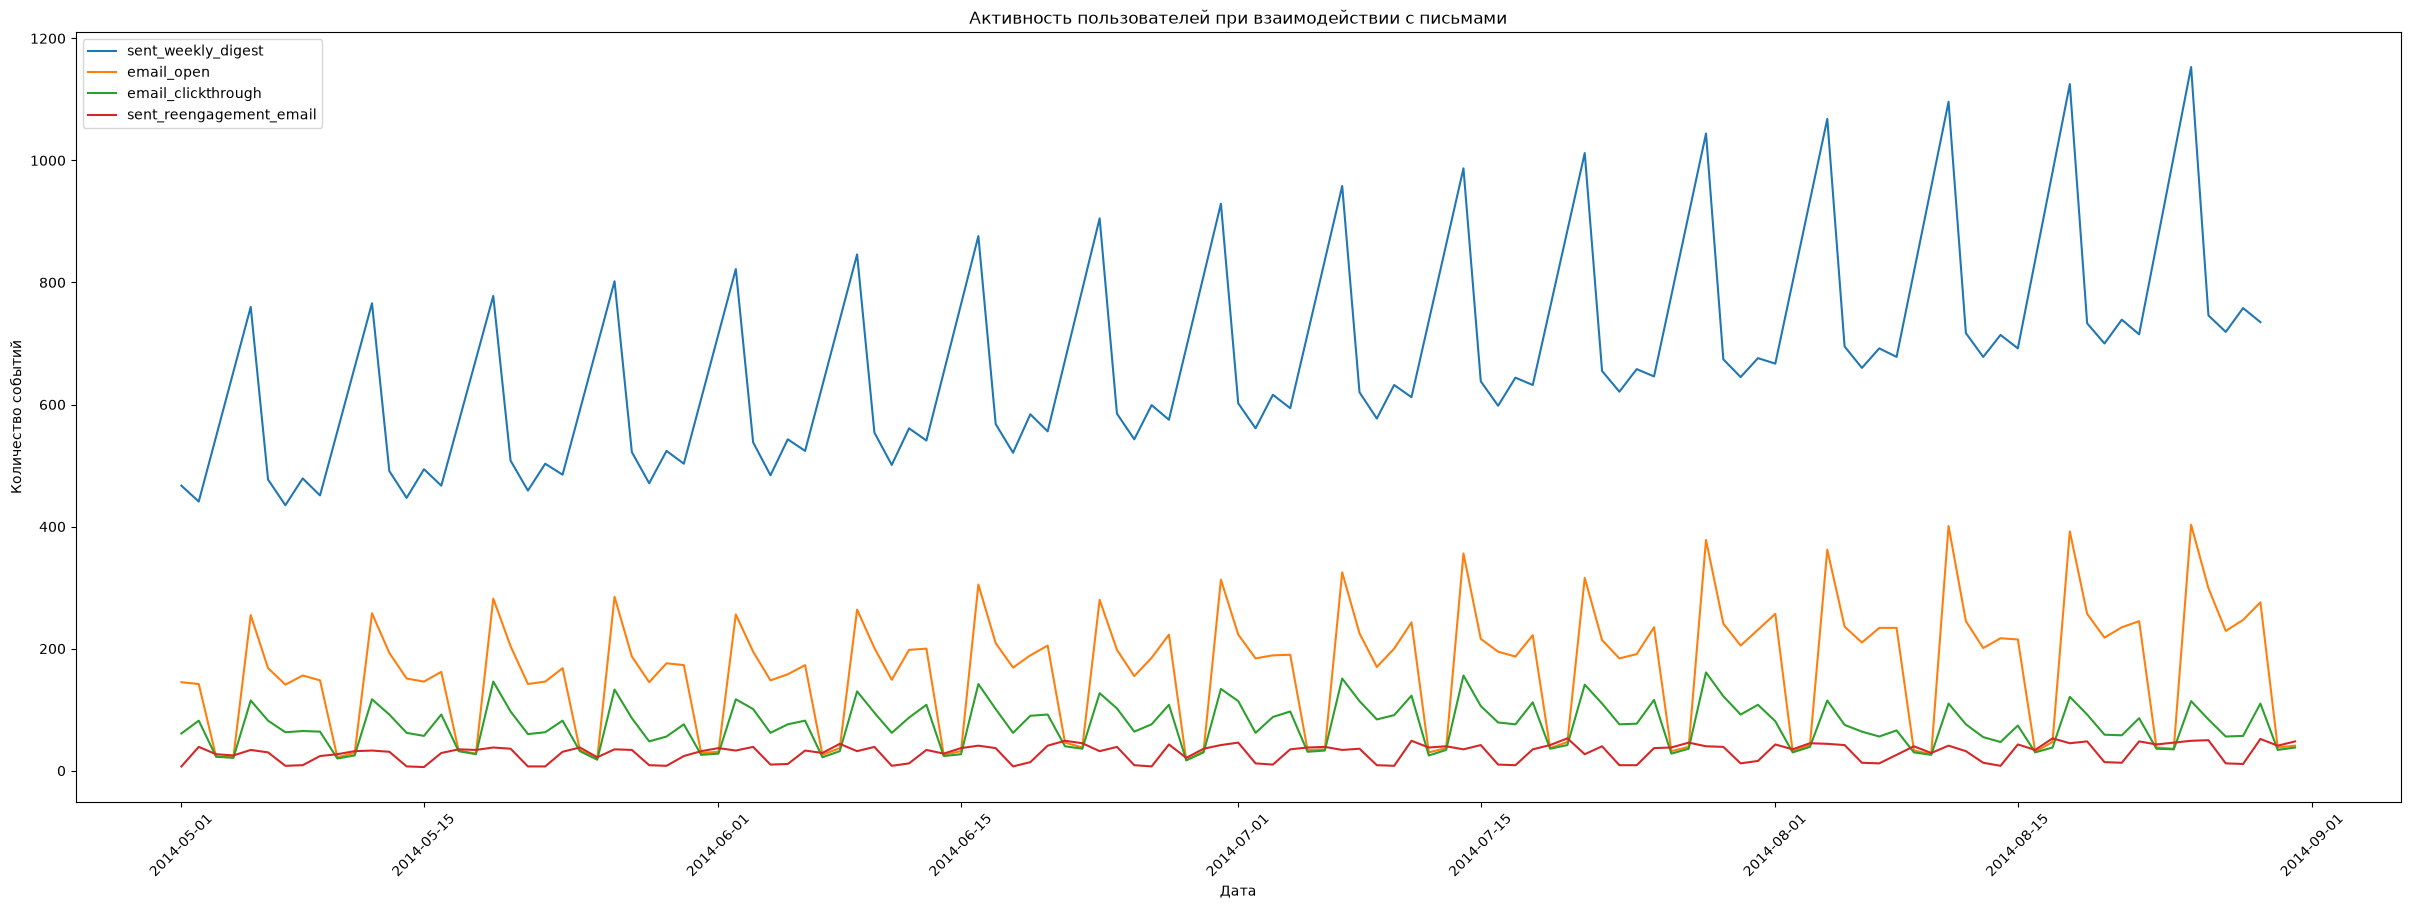

In [27]:
plt.figure(figsize=(30, 10))

emails_activity['day'] = pd.to_datetime(emails_activity['day'])

for action in emails_activity['action'].unique():
    data = emails_activity[emails_activity['action'] == action]

    plt.plot(
        data['day'],
        data['events_count'],
        label=action
    )

plt.title('Активность пользователей при взаимодействии с письмами')
plt.xlabel('Дата')
plt.ylabel('Количество событий')
plt.xticks(rotation=45)
plt.legend()
plt.show()

Видим, что со временем писем отправляется все больше, но это не влияет на открытие ссылки из письма. 

Переходим к исследованию таблицы events

In [28]:
pd.read_sql_query(
"""
SELECT
    COUNT(DISTINCT user_id) AS unique_users
FROM events;
""", conn)

,unique_users
0,9760


Разделим события по статусу акаунта и типу события. В каждой группе посчитаем количество событий и количество уникальных пользователей.

In [29]:
pd.read_sql_query(
"""
SELECT
	u.state,
    e.event_type,
    COUNT(*) AS events_cnt,
    COUNT(DISTINCT e.user_id) AS unique_users
FROM events AS e
JOIN users AS u
	ON e.user_id = u.user_id
GROUP BY
	u.state,
    e.event_type
""", conn)

,state,event_type,events_cnt,unique_users
0,active,engagement,321575,6142
1,active,signup_flow,14720,3680
2,pending,signup_flow,4537,3618


Видим что для пользоватей без активации акаунта есть только события процесса регистрации. Тогда как у активных пользователей дополнительно есть события события взаимодействия с платформой.

Посмотрим на то, сколько событий в каждом типе, а так же сколько уникальных пользователей совершали действия.

In [30]:
pd.read_sql_query(
"""
SELECT
    event_type,
    COUNT(*) AS events_cnt,
    COUNT(DISTINCT user_id) AS unique_users
FROM events
GROUP BY event_type
ORDER BY events_cnt DESC;
""", conn)

,event_type,events_cnt,unique_users
0,engagement,321575,6142
1,signup_flow,19257,7298


Добавим к предыдущему выводу группировке по имени события. 

In [31]:
pd.read_sql_query(
"""
SELECT
    event_type,
    event_name,
    COUNT(*) AS events_cnt,
    COUNT(DISTINCT user_id) AS unique_users
FROM events
GROUP BY event_type, event_name
ORDER BY event_type, events_cnt DESC;
""", conn)

,event_type,event_name,events_cnt,unique_users
0,engagement,home_page,94065,5966
1,engagement,like_message,59248,5570
2,engagement,view_inbox,55936,5499
3,engagement,login,38610,6142
4,engagement,send_message,33105,4917
5,engagement,search_autocomplete,17820,4033
6,engagement,search_run,13019,2178
7,engagement,search_click_result_2,1499,786
8,engagement,search_click_result_1,1413,761
9,engagement,search_click_result_4,1264,707


Найдем временной интервал данных

In [32]:
pd.read_sql_query(
"""
SELECT
    MIN(occurred_at) AS min_date,
    MAX(occurred_at) AS max_date,
    timediff(MAX(occurred_at), MIN(occurred_at)) AS period,
    JULIANDAY(MAX(occurred_at)) - JULIANDAY(MIN(occurred_at)) AS period_days
FROM events;
""", conn)

,min_date,max_date,period,period_days
0,2014-05-01 00:54:09,2014-08-31 23:03:39,+0000-03-30 22:09:30.000,122.923264


Найдем границы отслеживания событий engagement.

In [33]:
pd.read_sql_query(
"""
SELECT
    MIN(occurred_at) AS min_date,
    MAX(occurred_at) AS max_date,
    timediff(MAX(occurred_at), MIN(occurred_at)) AS period,
    JULIANDAY(MAX(occurred_at)) - JULIANDAY(MIN(occurred_at)) AS period_days
FROM events
WHERE event_type = 'engagement';
""", conn)

,min_date,max_date,period,period_days
0,2014-05-01 02:27:15,2014-08-31 23:03:39,+0000-03-30 20:36:24.000,122.858611


Посмотрим какие устройства используют пользователи.

In [34]:
pd.read_sql_query(
"""
SELECT
    device,
    COUNT(*) AS events_cnt,
    COUNT(DISTINCT user_id) AS unique_users
FROM events
GROUP BY device
ORDER BY events_cnt DESC;
""", conn)

,device,events_cnt,unique_users
0,macbook pro,59948,2559
1,lenovo thinkpad,38679,1727
2,macbook air,28104,1268
3,iphone 5,27134,1291
4,dell inspiron notebook,20476,848
5,samsung galaxy s4,19594,1027
6,nexus 5,17249,819
7,iphone 5s,16705,798
8,dell inspiron desktop,10569,450
9,iphone 4s,10097,531


Узнаем какие страны представленны в данных.

In [35]:
pd.read_sql_query(
"""
SELECT
    location,
    COUNT(*) AS events_cnt,
    COUNT(DISTINCT user_id) AS unique_users
FROM events
GROUP BY location
ORDER BY events_cnt DESC;
""", conn)

,location,events_cnt,unique_users
0,United States,94728,2762
1,Japan,26046,745
2,Germany,23524,606
3,France,17364,468
4,United Kingdom,16475,448
5,Russia,12226,352
6,Italy,11790,361
7,Brazil,11240,335
8,India,9620,306
9,Canada,9126,289


Узнаем как распределены события по типу пользователя. 

In [36]:
pd.read_sql_query(
"""
SELECT
    user_type,
    COUNT(*) AS events_cnt,
    COUNT(DISTINCT user_id) AS unique_users
FROM events
GROUP BY user_type
ORDER BY events_cnt DESC;
""", conn)

,user_type,events_cnt,unique_users
0,1.0,210662,1785
1,2.0,62578,1727
2,3.0,52015,2630
3,NaN,15577,7298


Построим гистограммы для трех типов пользователей.

In [37]:
user_types_distribution = pd.read_sql_query(
"""
SELECT
	user_type,
	user_id,
    COUNT(*) AS cnt
FROM events
WHERE user_type IS NOT NULL 
GROUP BY user_type, user_id
""", conn)

user_types_distribution

,user_type,user_id,cnt
0,1,11,126
1,1,17,55
2,1,19,71
3,1,22,357
4,1,59,257
...,...,...,...
6137,3,19049,5
6138,3,19050,5
6139,3,19055,3
6140,3,19059,3


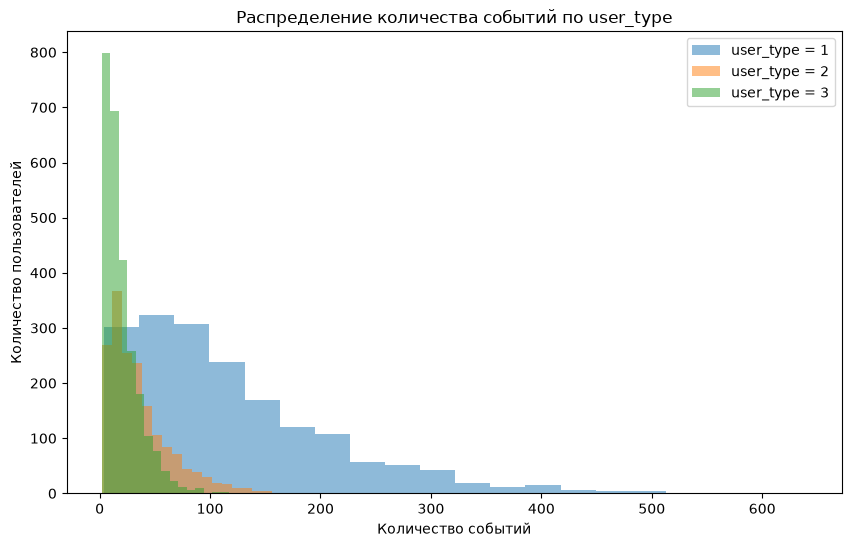

In [38]:
plt.figure(figsize=(10, 6))

for user_type in [1, 2, 3]:
    data = user_types_distribution[
        user_types_distribution['user_type'] == user_type
    ]['cnt']

    plt.hist(
        data,
        bins=20,
        alpha=0.5,
        label=f'user_type = {user_type}'
    )

plt.xlabel('Количество событий')
plt.ylabel('Количество пользователей')
plt.title('Распределение количества событий по user_type')
plt.legend()
plt.show()

Посмотрим на статистические характеристики.

In [65]:
user_types_distribution.groupby('user_type')['cnt'].agg(
    ['count', 'mean', 'median', 'std']
)

,count,mean,median,std
user_type,,,,
1,1785,118.017927,94.0,93.140340
2,1727,36.235090,28.0,28.269115
3,2630,19.777567,15.0,16.226793


Проведем непараметрический тест Краскела — Уоллиса, нулевая гипотеза которого в том что медианы (средние) групп не имеют различий. Проверим гипотезу на уровне значимости 0.05 (5%). 

In [71]:
from scipy.stats import kruskal

groups = [
    user_types_distribution[
        user_types_distribution['user_type'] == user_type
    ]['cnt']
    for user_type in [1, 2, 3]
]

stat, p_value = kruskal(*groups)

print(f'H-statistic: {stat:.3f}')
print(f'p-value: {p_value:.3f}')

H-statistic: 2508.138
p-value: 0.000


Отвергаем гипотезу о равенстве медиан (средних) в пользу альтернативы на урвне значимости 0.05.

P.S. Вообще критерий проверяет есть ли статистически значимый сдвиг между распределениями. То есть для одинаковых распределений это может быть как медиана так и среднее и они сдвигаются на одинаковую величину. Но в нашем случае распределения все таки немного различаются.

Попарно сравним все три группы между собой ранговым критерием Манна-Уитни с альтернативой доминирования. Так же используем поправку Бонферрони на множественное тестирование.

In [92]:
from scipy.stats import mannwhitneyu

alpha = 0.05
n_tests = 3
alpha_corrected = alpha / n_tests

for i in [1, 2, 3]:
    for j in range(i + 1, 4):
        x = user_types_distribution[
            user_types_distribution['user_type'] == i
        ]['cnt']

        y = user_types_distribution[
            user_types_distribution['user_type'] == j
        ]['cnt']

        stat, p = mannwhitneyu(x, y, alternative='greater')

        print(f'{i} и {j}: p={p:.3f}, Результат={p < alpha_corrected}')

1 и 2: p=0.000, Результат=True
1 и 3: p=0.000, Результат=True
2 и 3: p=0.000, Результат=True


Все три теста показали статистически значимые различия в средних между группами. Таким образом можно сделать вывод о том, что user_type зависит от количества совершаемых пользователем действий.

Найдем пользователей с наибольшим числом событий.

In [89]:
users_events = pd.read_sql_query(
"""
SELECT
    user_id,
    COUNT(*) AS events_cnt
FROM events
GROUP BY user_id
ORDER BY events_cnt DESC
""", conn)

users_events.head(10)

,user_id,events_cnt
0,3390,640
1,10276,561
2,3774,525
3,10498,512
4,2419,502
5,5633,500
6,8733,492
7,3720,487
8,12389,477
9,2398,461


Построим распределение пользователей по количеству совершённых событий в логарифмическом масштабе.

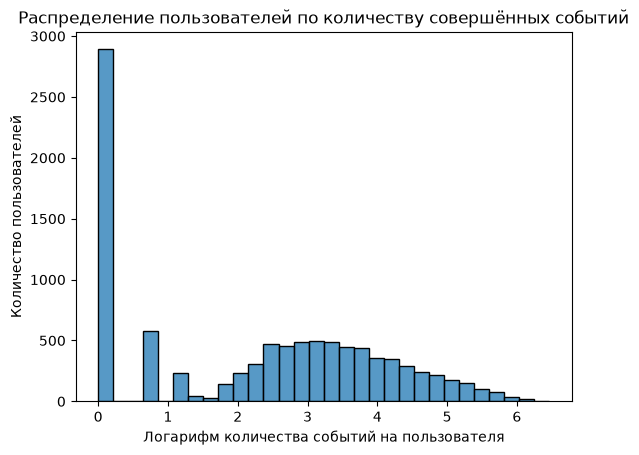

In [41]:
sns.histplot(np.log(users_events['events_cnt']), bins=30)

plt.title('Распределение пользователей по количеству совершённых событий')
plt.xlabel('Логарифм количества событий на пользователя')
plt.ylabel('Количество пользователей')
plt.show()

Видим что около трех тысяч пользователей совершили всего одно действие. Основное распределение скошено влево.   

Отследим динамику количества событий по дням. 

In [42]:
events_activity = pd.read_sql_query(
"""
SELECT
	DATE(occurred_at) as day,
    COUNT(*) AS events_cnt
FROM events
GROUP BY DATE(occurred_at);
""", conn)

events_activity

,day,events_cnt
0,2014-05-01,3061
1,2014-05-02,4005
2,2014-05-03,1338
3,2014-05-04,745
4,2014-05-05,2723
...,...,...
118,2014-08-27,2851
119,2014-08-28,3068
120,2014-08-29,3769
121,2014-08-30,1549


Text(0, 0.5, 'Количество событий')

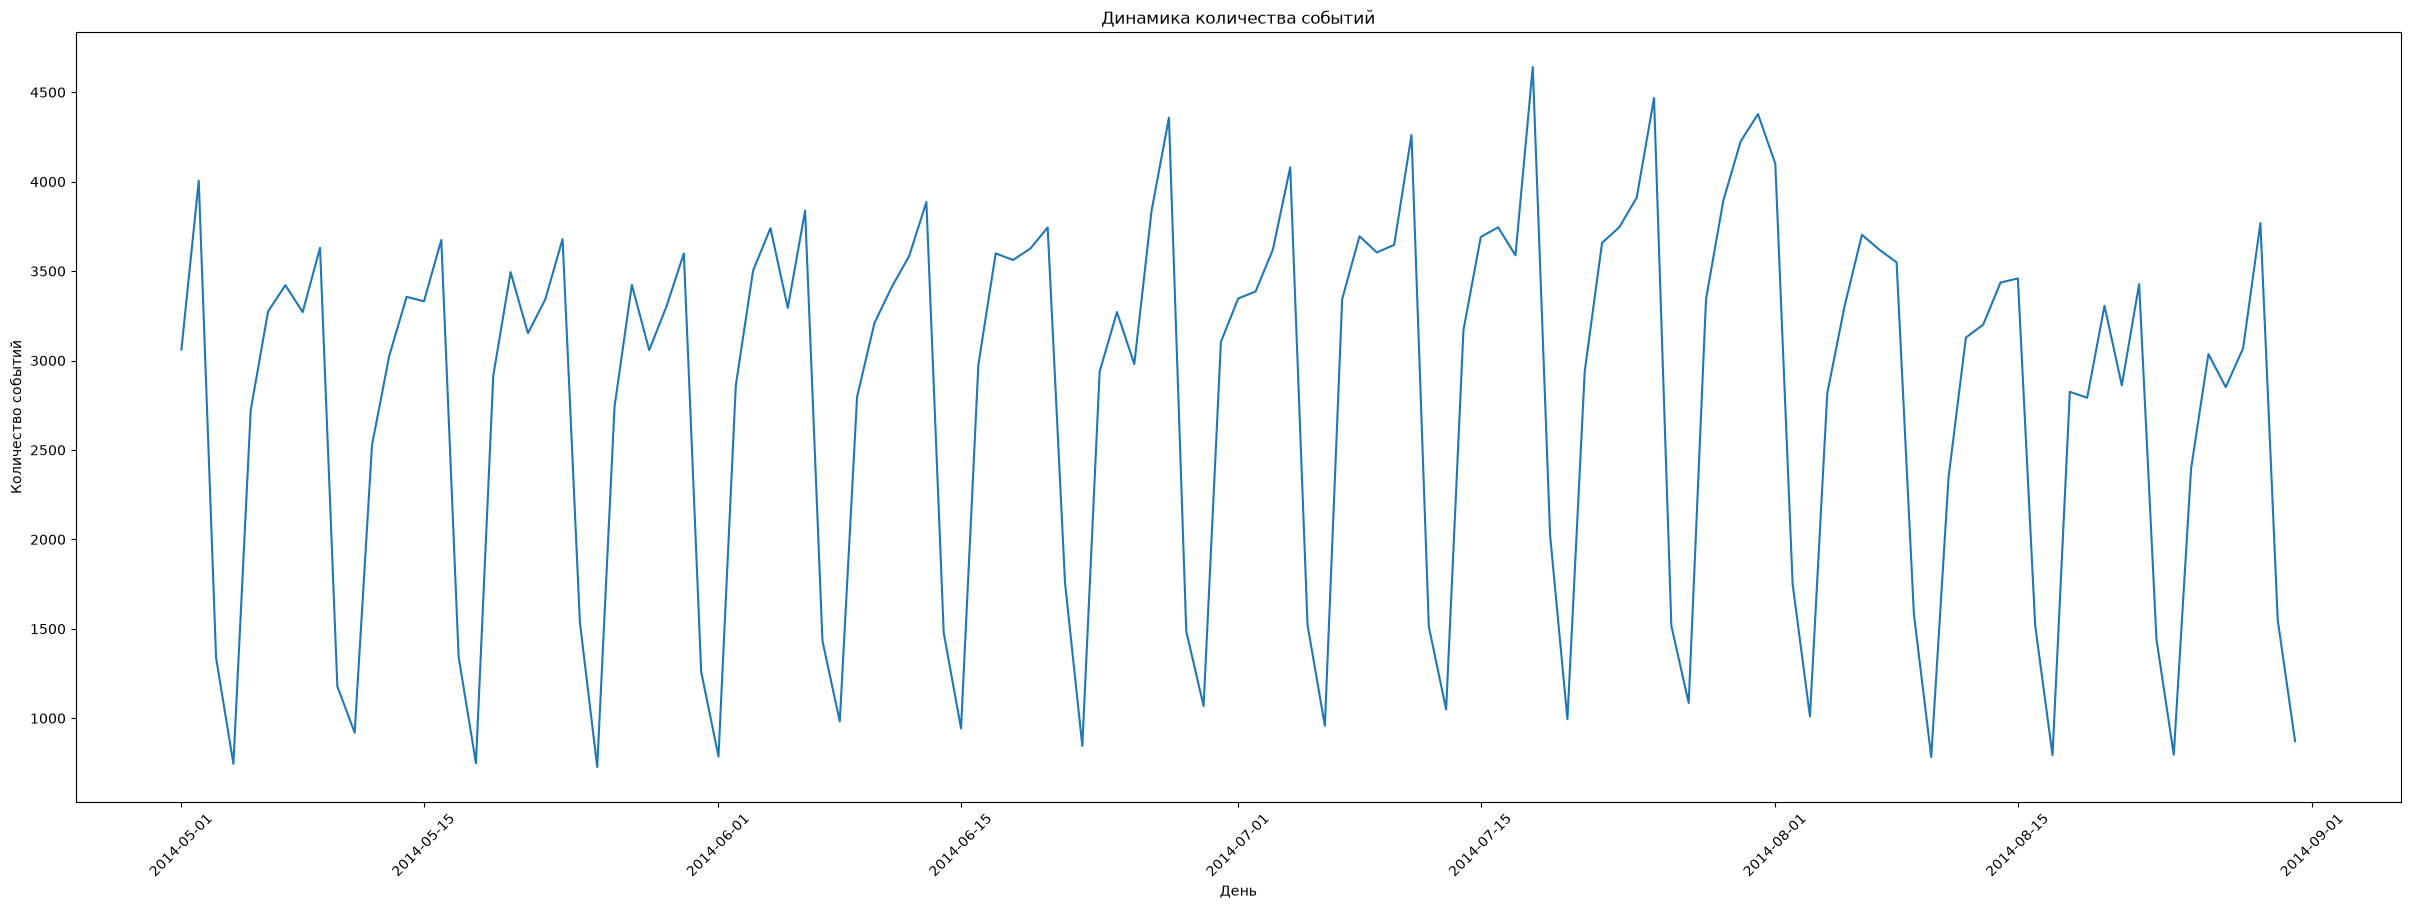

In [43]:
plt.figure(figsize=(30,10))
events_activity['day'] = pd.to_datetime(events_activity['day'])

plt.plot(events_activity['day'], events_activity['events_cnt'])

plt.xticks(rotation=45)
plt.title('Динамика количества событий')
plt.xlabel('День')
plt.ylabel('Количество событий')

Видим некоторую сезонность в данных. В остальном никаких критических изменений не наблюдается. 

Разделим события по типам и так же построим график динамики.

In [44]:
events_activity_per_type = pd.read_sql_query(
"""
SELECT
	DATE(occurred_at) as day,
    event_type,
    COUNT(*) AS events_cnt
FROM events
GROUP BY
	day,
    event_type;
""", conn)

events_activity_per_type

,day,event_type,events_cnt
0,2014-05-01,engagement,2874
1,2014-05-01,signup_flow,187
2,2014-05-02,engagement,3854
3,2014-05-02,signup_flow,151
4,2014-05-03,engagement,1291
...,...,...,...
241,2014-08-29,signup_flow,251
242,2014-08-30,engagement,1482
243,2014-08-30,signup_flow,67
244,2014-08-31,engagement,784


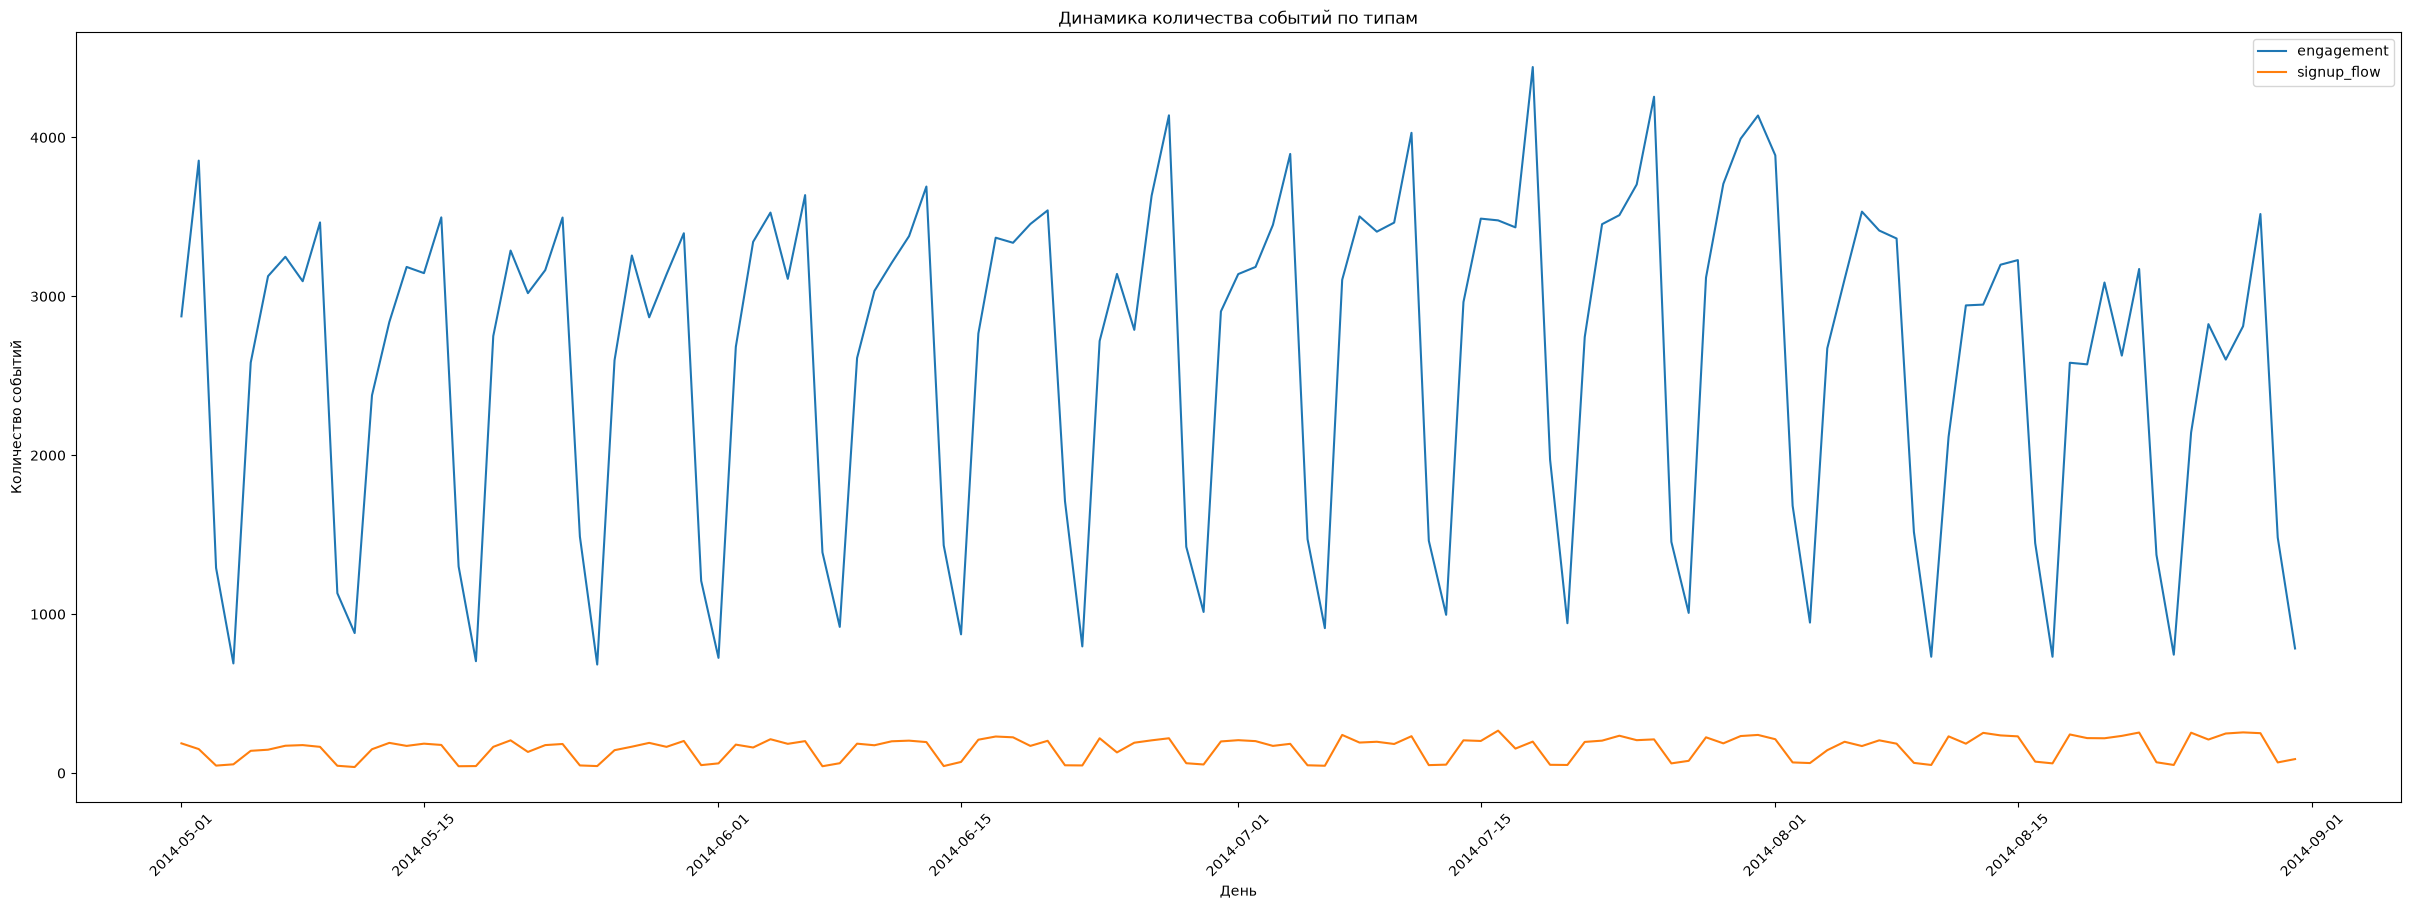

In [45]:
plt.figure(figsize=(30,10))
events_activity_per_type['day'] = pd.to_datetime(events_activity_per_type['day'])

event_types = events_activity_per_type['event_type'].unique()

for event_type in event_types:
	data = events_activity_per_type[events_activity_per_type['event_type'] == event_type]
	plt.plot(data['day'], data['events_cnt'], label=event_type)

plt.title('Динамика количества событий по типам')
plt.xlabel('День')
plt.ylabel('Количество событий')
plt.xticks(rotation=45)
plt.legend()
plt.show()

Посмотрим на число уникальных пользователей которые создают события по неделям при разделении по типам.

In [46]:
week_event_activity_per_type = pd.read_sql_query(
"""
SELECT
    strftime('%Y-%W', occurred_at) AS week,
    event_type,
    COUNT(DISTINCT user_id) AS unique_users
FROM events
GROUP BY
	week,
    event_type
ORDER BY week;
""", conn)

week_event_activity_per_type

,week,event_type,unique_users
0,2014-17,engagement,701
1,2014-17,signup_flow,171
2,2014-18,engagement,1054
3,2014-18,signup_flow,350
4,2014-19,engagement,1094
5,2014-19,signup_flow,362
6,2014-20,engagement,1147
7,2014-20,signup_flow,371
8,2014-21,engagement,1113
9,2014-21,signup_flow,366


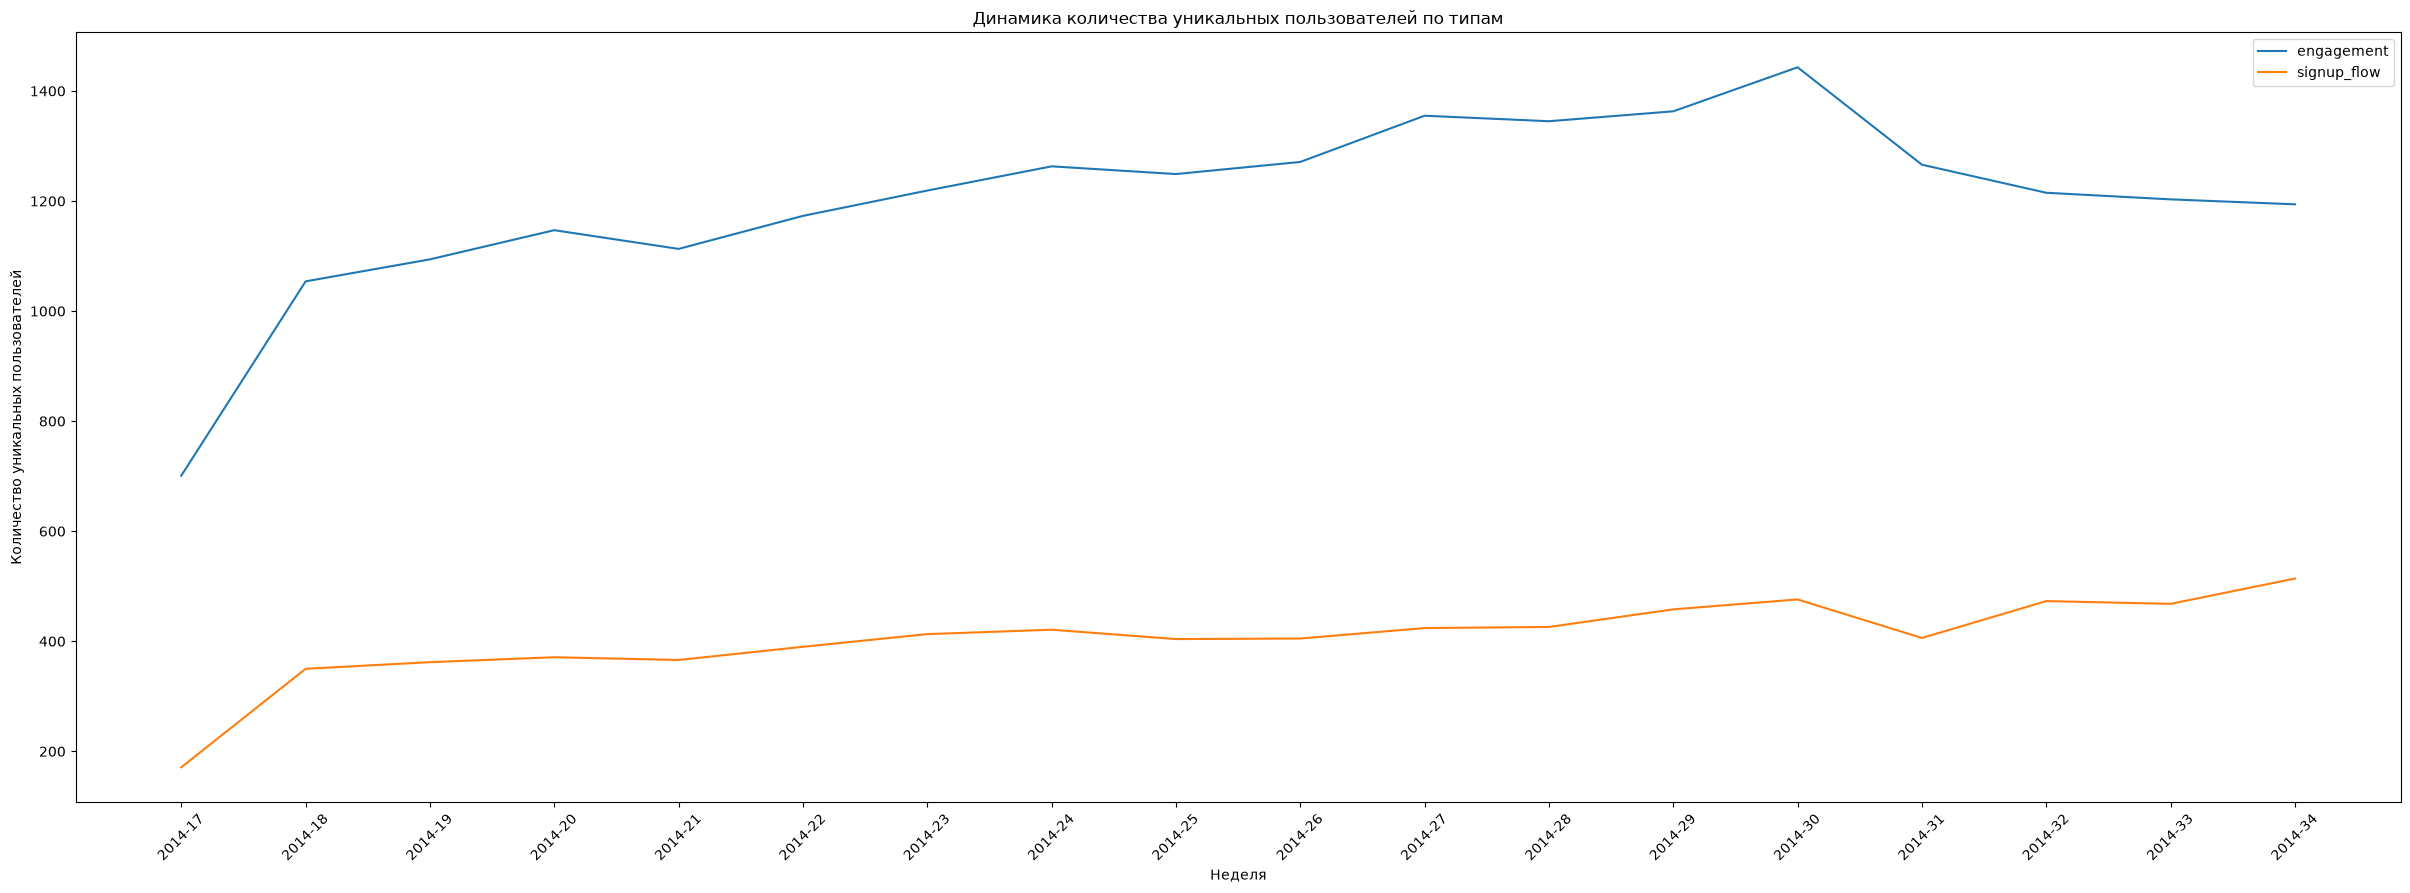

In [47]:
plt.figure(figsize=(30,10))

event_types = week_event_activity_per_type['event_type'].unique()

for event_type in event_types:
	data = week_event_activity_per_type[week_event_activity_per_type['event_type'] == event_type]
	plt.plot(data['week'], data['unique_users'], label=event_type)

plt.title('Динамика количества уникальных пользователей по типам')
plt.xlabel('Неделя')
plt.ylabel('Количество уникальных пользователей')
plt.xticks(rotation=45)
plt.legend()
plt.show()

Видим, что на 30 неделе есть четкое падение событий вовлеченности. Тогда как событий у регистрации число уникальных пользователей не поменялось.

Попробуем локализовать источник сделав разбьение по типам устройств.

In [48]:
week_event_activity_per_device = pd.read_sql_query(
"""
SELECT
    strftime('%Y-%W', occurred_at) AS week,
    
    CASE
        WHEN LOWER(device) LIKE '%ipad%'
          OR LOWER(device) LIKE '%nexus 7%'
          OR LOWER(device) LIKE '%nexus 10%'
          OR LOWER(device) LIKE '%kindle fire%'
          OR LOWER(device) LIKE '%tablet%'
        THEN 'tablet'

        WHEN LOWER(device) LIKE '%iphone%'
          OR LOWER(device) LIKE '%galaxy%'
          OR LOWER(device) LIKE '%lumia%'
          OR LOWER(device) LIKE '%htc%'
          OR LOWER(device) LIKE '%fire phone%'
          OR LOWER(device) LIKE '%nexus 5%'
        THEN 'mobile'

        ELSE 'desktop_laptop'
    END AS device_type,

    COUNT(DISTINCT user_id) AS unique_users
FROM events
WHERE event_type = 'engagement'
GROUP BY
    week,
    device_type
ORDER BY
    week,
    device_type;
""", conn)

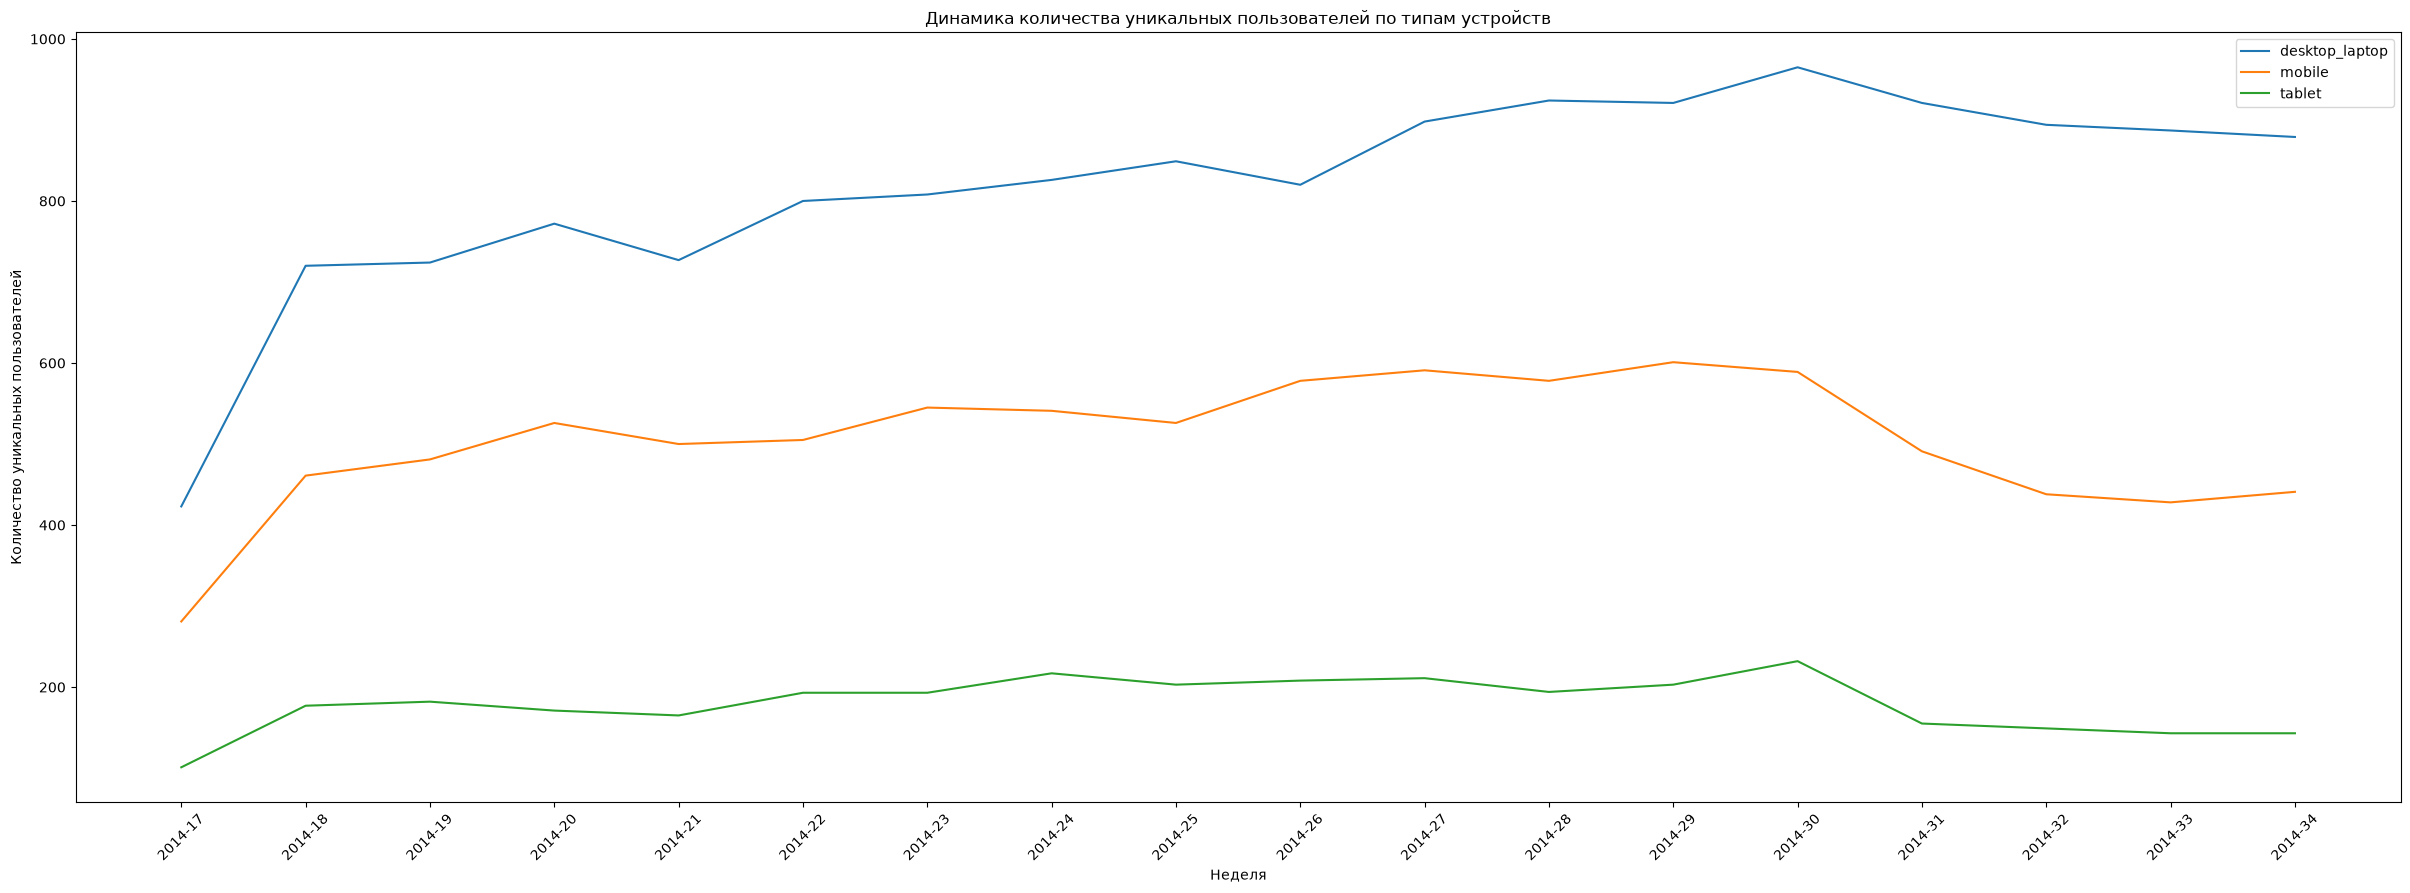

In [49]:
plt.figure(figsize=(30,10))

device_types = week_event_activity_per_device['device_type'].unique()

for device_type in device_types:
	data = week_event_activity_per_device[week_event_activity_per_device['device_type'] == device_type]
	plt.plot(data['week'], data['unique_users'], label=device_type)

plt.title('Динамика количества уникальных пользователей по типам устройств')
plt.xlabel('Неделя')
plt.ylabel('Количество уникальных пользователей')
plt.xticks(rotation=45)
plt.legend()
plt.show()

Разбиение по типам устройств не дало значимых резульатов. Во всех группах наблюдается спад вовлеченности.

Попробуем разделить на имя события.

In [50]:
week_event_activity_per_name = pd.read_sql_query(
"""
SELECT
    strftime('%Y-%W', occurred_at) AS week,
    event_name,
    COUNT(DISTINCT user_id) AS unique_users
FROM events
WHERE event_type = 'engagement'
	AND event_name NOT LIKE 'search_click_result_%'
GROUP BY
	week,
    event_name
ORDER BY week;
""", conn)

week_event_activity_per_name

,week,event_name,unique_users
0,2014-17,home_page,646
1,2014-17,like_message,564
2,2014-17,login,701
3,2014-17,search_autocomplete,200
4,2014-17,search_run,86
...,...,...,...
121,2014-34,login,1194
122,2014-34,search_autocomplete,454
123,2014-34,search_run,151
124,2014-34,send_message,746


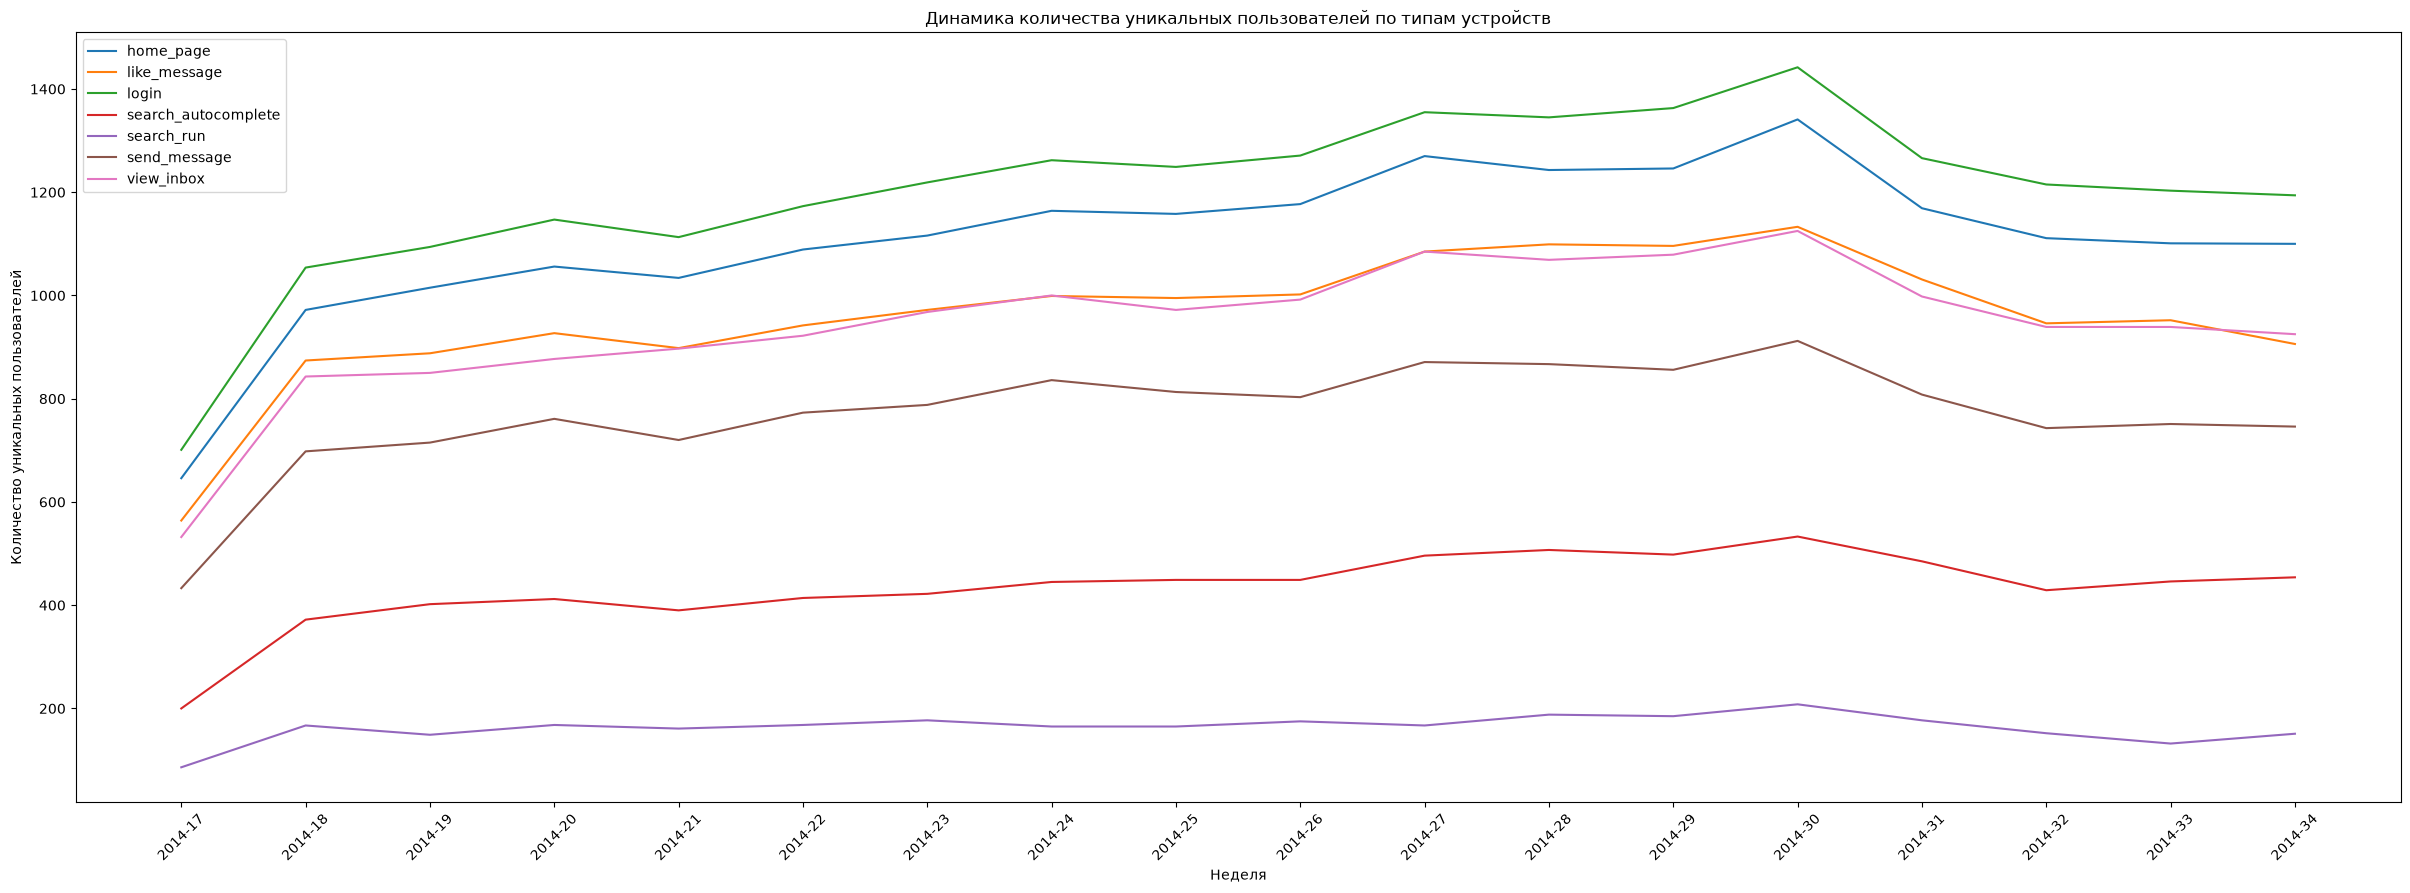

In [51]:
plt.figure(figsize=(30,10))

event_names = week_event_activity_per_name['event_name'].unique()

for event_name in event_names:
	data = week_event_activity_per_name[week_event_activity_per_name['event_name'] == event_name]
	plt.plot(data['week'], data['unique_users'], label=event_name)

plt.title('Динамика количества уникальных пользователей по типам устройств')
plt.xlabel('Неделя')
plt.ylabel('Количество уникальных пользователей')
plt.xticks(rotation=45)
plt.legend()
plt.show()

Это так же не дало видимого результата, во всех событиях наблюдается уменьшение количества пользователей.

Посмотрим на то какие пользователи отвалились начиная с 30 недели до 34 недели. Посчитаем их количество и процент. Если конкретнее, то узнаем сколько пользователей которые пользовались нашим сервисом в 30 неделю перестали пользоваться им на 34 неделю в разбиении по локации.

In [52]:
pd.read_sql_query(
"""
WITH week_30 AS (
    SELECT DISTINCT
        user_id,
        location
    FROM events
    WHERE event_type = 'engagement'
      AND strftime('%Y-%W', occurred_at) = '2014-30'
),

week_34 AS (
    SELECT DISTINCT
        user_id
    FROM events
    WHERE event_type = 'engagement'
      AND strftime('%Y-%W', occurred_at) = '2014-34'
)

SELECT
    w30.location,
    COUNT(w30.user_id) AS users_week_30,
    COUNT(w34.user_id) AS users_week_34,
    COUNT(w30.user_id) - COUNT(w34.user_id) AS lost_users,
    ROUND(
        (COUNT(w30.user_id) - COUNT(w34.user_id)) * 100.0
        / COUNT(w30.user_id),
        2
    ) AS lost_pct

FROM week_30 AS w30

LEFT JOIN week_34 AS w34
    ON w30.user_id = w34.user_id

GROUP BY w30.location
ORDER BY lost_pct DESC;
""", conn)

,location,users_week_30,users_week_34,lost_users,lost_pct
0,Thailand,10,0,10,100.00
1,Norway,7,0,7,100.00
2,Hong Kong,7,0,7,100.00
3,Saudi Arabia,17,1,16,94.12
4,Canada,37,4,33,89.19
5,Switzerland,17,2,15,88.24
6,United Arab Emirates,8,1,7,87.50
7,Japan,108,15,93,86.11
8,France,71,10,61,85.92
9,Singapore,7,1,6,85.71


Построим таблицу Retention. В качестве когорт возьмем неделю активации.

In [53]:
retention = pd.read_sql_query(
"""
    WITH cohort AS (
        SELECT
            user_id,
            date(activated_at, 'weekday 0', '-6 days') AS first_week
        FROM users
        WHERE state = 'active'
    ),
    cohort_size AS (
        SELECT first_week, COUNT(*) AS size
        FROM cohort
        GROUP BY first_week
    ),
    activity AS (
        SELECT DISTINCT
            user_id,
            date(occurred_at, 'weekday 0', '-6 days') AS activity_week
        FROM events
        WHERE event_type = 'engagement'
    )
    SELECT
        strftime('%Y-%W', c.first_week) AS first_week,
        CAST((julianday(a.activity_week) - julianday(c.first_week)) / 7.0 AS INTEGER) AS weeks_since_activation,
        cs.size AS cohort_size,
        COUNT(DISTINCT c.user_id) AS retained_users,
        ROUND(COUNT(DISTINCT c.user_id) * 100.0 / cs.size, 2) AS retention_pct
    FROM cohort c
    JOIN cohort_size cs ON c.first_week = cs.first_week
    JOIN activity a ON c.user_id = a.user_id
    WHERE a.activity_week >= c.first_week
    GROUP BY c.first_week, weeks_since_activation, cs.size
    ORDER BY c.first_week, weeks_since_activation;
""", conn)
retention

,first_week,weeks_since_activation,cohort_size,retained_users,retention_pct
0,2012-53,69,26,2,7.69
1,2012-53,70,26,3,11.54
2,2012-53,71,26,3,11.54
3,2012-53,72,26,3,11.54
4,2012-53,73,26,2,7.69
...,...,...,...,...,...
1401,2014-32,1,250,163,65.20
1402,2014-32,2,250,82,32.80
1403,2014-33,0,259,259,100.00
1404,2014-33,1,259,173,66.80


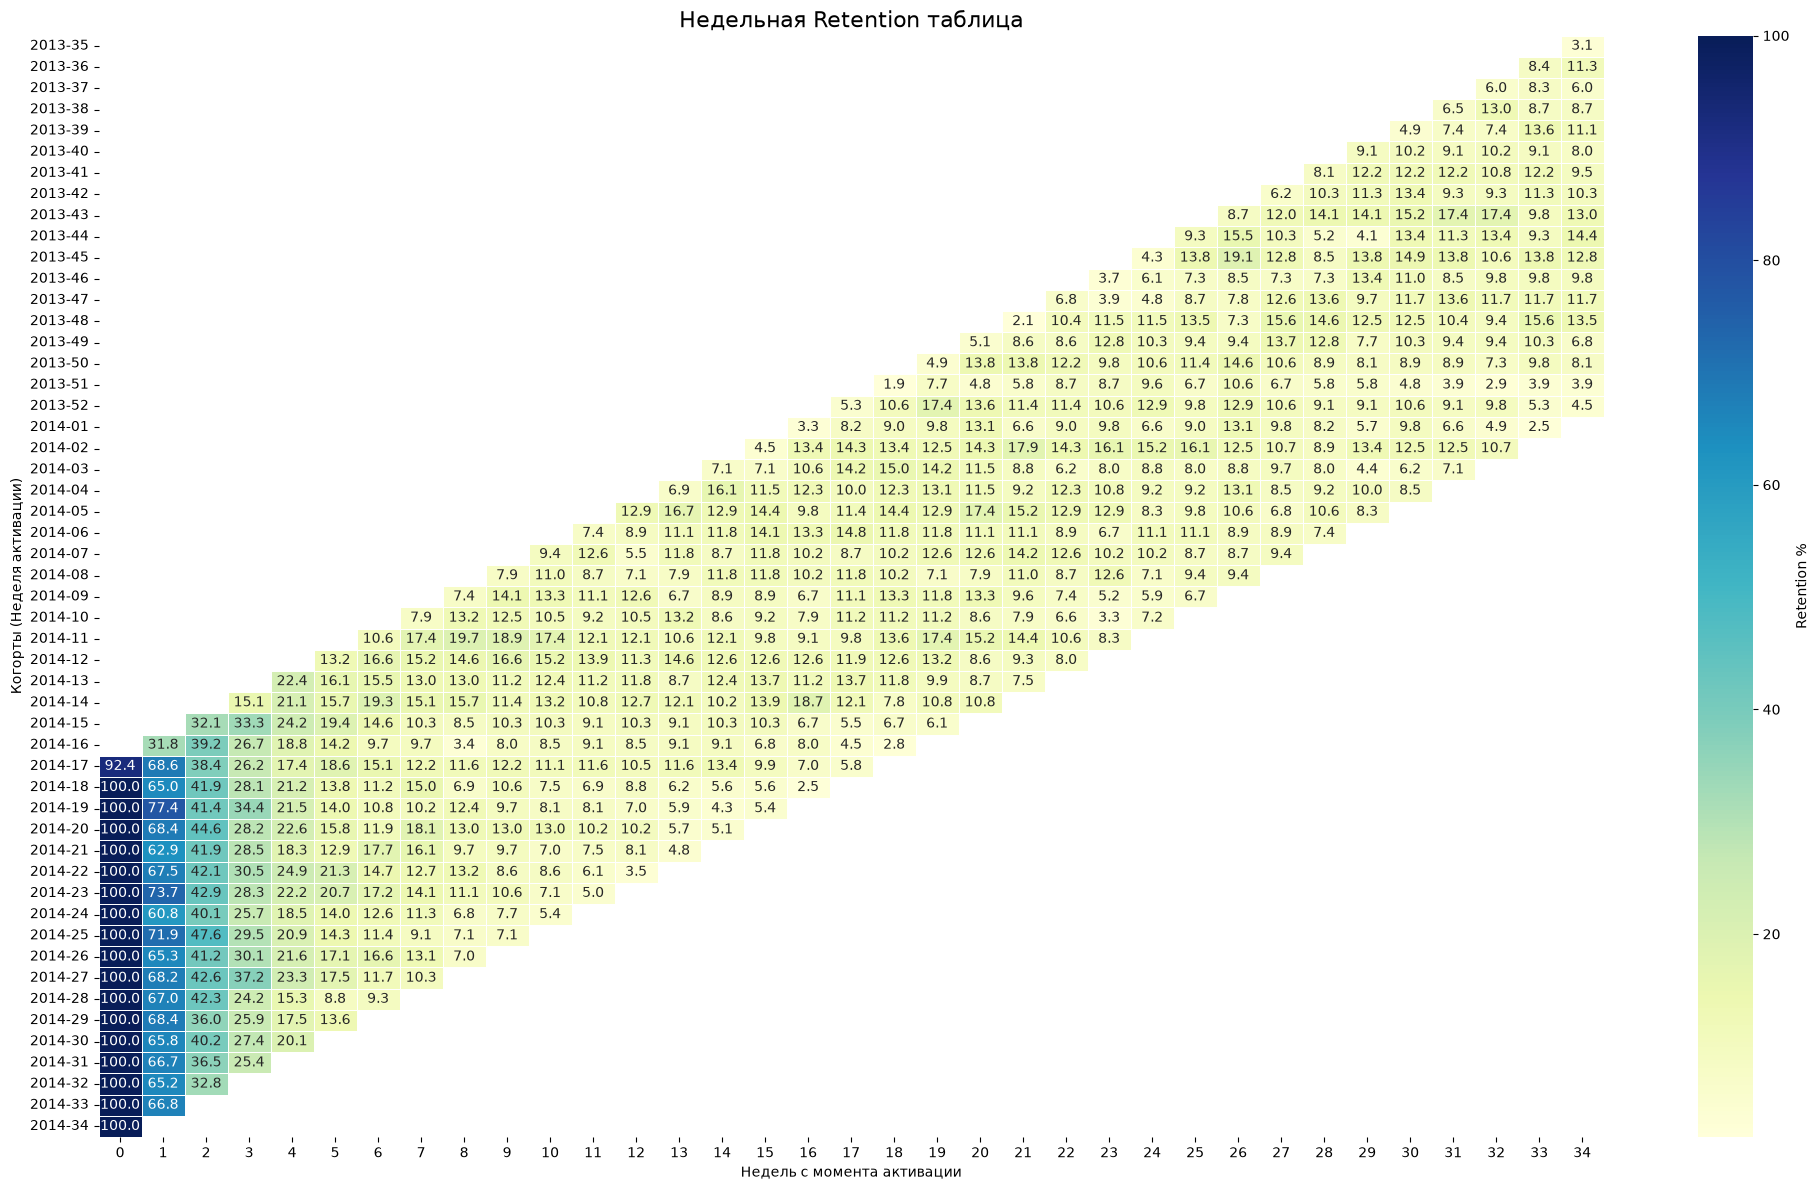

In [54]:
MIN_RETENTION_WEEK = 0
MAX_RETENTION_WEEK = 34

retention_for_plot = retention[
    retention['weeks_since_activation'].between(
        MIN_RETENTION_WEEK,
        MAX_RETENTION_WEEK
    )
]

pivot = retention_for_plot.pivot_table(
    index='first_week',
    columns='weeks_since_activation',
    values='retention_pct'
)

plt.figure(figsize=(20, 12))
sns.heatmap(
    pivot,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu',
    linewidths=0.5,
    cbar_kws={'label': 'Retention %'}
)

plt.title('Недельная Retention таблица', fontsize=16)
plt.xlabel('Недель с момента активации')
plt.ylabel('Когорты (Неделя активации)')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Видим над диагональю пустые значения. Это связанно с тем что отслеживание событий engagment началось в 2014-W18.

Перейдем к анализу таблицы experiments

Посмотрим на основные метрики таблицы.

In [94]:
pd.read_sql_query(
"""
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT user_id) AS unique_users,
    COUNT(DISTINCT experiment) AS experiments_count,
    COUNT(DISTINCT experiment_group) AS groups_count,
    MIN(occurred_at) AS min_date,
    MAX(occurred_at) AS max_date,
    timediff(MAX(occurred_at), MIN(occurred_at)) AS period,
    JULIANDAY(MAX(occurred_at)) - JULIANDAY(MIN(occurred_at)) AS period_days
FROM experiments;
""", conn)

,total_rows,unique_users,experiments_count,groups_count,min_date,max_date,period,period_days
0,2595,2595,1,2,2014-06-01 00:13:07,2014-06-30 22:45:01,+0000-00-29 22:31:54.000,29.938819


Один эксперимент (publisher_update), 2 группы, 2595 пользователей, один месяц.

In [95]:
exp_group_sizes = pd.read_sql_query(
"""
SELECT
	experiment_group,
    COUNT(DISTINCT user_id) AS unique_users,
    ROUND((COUNT(DISTINCT user_id) * 100.0) / SUM(COUNT(DISTINCT user_id)) OVER (PARTITION BY experiment), 2) AS experiment_pct
FROM experiments
GROUP BY experiment_group
ORDER BY unique_users DESC
""", conn)

exp_group_sizes

,experiment_group,unique_users,experiment_pct
0,control_group,1746,67.28
1,test_group,849,32.72


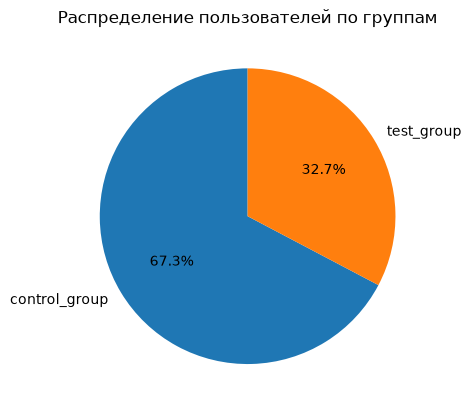

In [96]:
plt.pie(exp_group_sizes['unique_users'], labels=exp_group_sizes['experiment_group'],  autopct='%1.1f%%', startangle=90)

plt.title('Распределение пользователей по группам')
plt.show()


Видим, что грппы имеют разные размеры, примерно 2 к 1.

Сгруппируем пользователей из теста и контроля по типу устройства.

In [98]:
pd.read_sql_query("""
SELECT
    e.experiment_group,
    CASE
        WHEN LOWER(ev.device) LIKE '%ipad%'
          OR LOWER(ev.device) LIKE '%nexus 7%'
          OR LOWER(ev.device) LIKE '%nexus 10%'
          OR LOWER(ev.device) LIKE '%kindle fire%'
          OR LOWER(ev.device) LIKE '%tablet%'
          OR LOWER(ev.device) LIKE '%surface%'
        THEN 'tablet'
        
        WHEN LOWER(ev.device) LIKE '%iphone%'
          OR LOWER(ev.device) LIKE '%galaxy s4%'
          OR LOWER(ev.device) LIKE '%lumia%'
          OR LOWER(ev.device) LIKE '%htc%'
          OR LOWER(ev.device) LIKE '%fire phone%'
          OR LOWER(ev.device) LIKE '%nexus 5%'
          OR LOWER(ev.device) LIKE '%galaxy note%'
        THEN 'mobile'
        
        ELSE 'desktop'
    END AS device_type,
    
    COUNT(DISTINCT e.user_id) AS users_cnt,
    ROUND(COUNT(DISTINCT e.user_id) * 100.0 / SUM(COUNT(DISTINCT e.user_id)) OVER (PARTITION BY e.experiment_group), 2) AS pct
FROM experiments e
JOIN events ev ON e.user_id = ev.user_id
GROUP BY e.experiment_group, device_type
ORDER BY e.experiment_group, device_type;
""", conn)

,experiment_group,device_type,users_cnt,pct
0,control_group,desktop,1493,44.16
1,control_group,mobile,1280,37.86
2,control_group,tablet,608,17.98
3,test_group,desktop,789,41.44
4,test_group,mobile,749,39.34
5,test_group,tablet,366,19.22


Разница между соответсвующими группами около 3 п.п. Это допустимо

Сгруппируем пользователей по типу. 

In [119]:
count_users_per_type = pd.read_sql_query("""
SELECT
    e.experiment_group,
    e.user_type,
    COUNT(DISTINCT e.user_id) AS users_cnt,
    ROUND(COUNT(DISTINCT e.user_id) * 100.0 / SUM(COUNT(DISTINCT e.user_id)) OVER (PARTITION BY e.experiment_group), 2) AS pct
FROM experiments e
GROUP BY e.experiment_group, e.user_type
ORDER BY e.experiment_group, e.user_type;
""", conn)

count_users_per_type

,experiment_group,user_type,users_cnt,pct
0,control_group,1,498,28.52
1,control_group,2,474,27.15
2,control_group,3,774,44.33
3,test_group,1,394,46.41
4,test_group,2,210,24.73
5,test_group,3,245,28.86


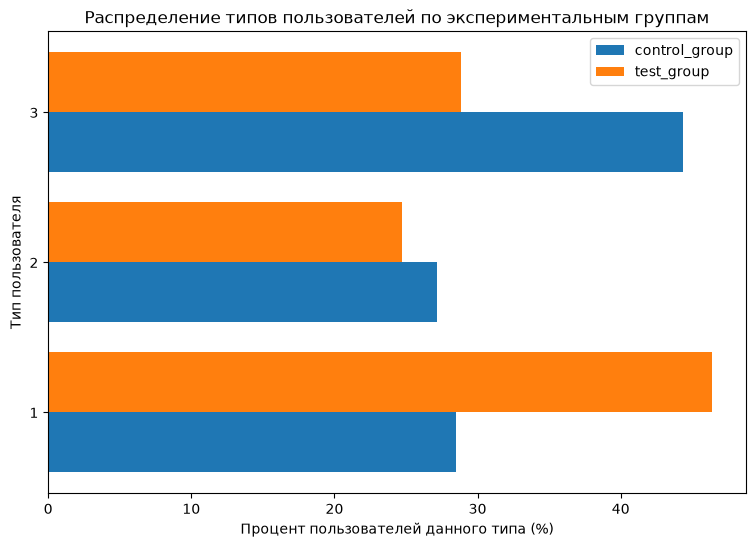

In [146]:
df = count_users_per_type.copy()
df['user_type'] = df['user_type'].astype(str)
user_types = df['user_type'].unique()
experiment_groups = df['experiment_group'].unique()

y = np.arange(len(user_types))

height = 0.4

plt.figure(figsize=(9, 6))

for i, experiment_group in enumerate(experiment_groups):
    data = df[df['experiment_group'] == experiment_group]

    plt.barh(
        y + i * height - height / 2, data['pct'], height=height, label=str(experiment_group))

plt.yticks(y, user_types)
plt.xlabel('Процент пользователей данного типа (%)')
plt.ylabel('Тип пользователя')
plt.title('Распределение типов пользователей по экспериментальным группам')
plt.legend()
plt.show()

Видим, что рандомизация по типу пользователя сломана. В тестовой группе в 1.6 раза больше пользователей типа 1 и в 1.5 раза меньше пользователей типа 3 по сравнению с контрольной группой.

При исследовании событий по типам пользователей мы установили самая активная группа - 1, самая пассивная - 3. Это может привести к неправильным выводам при интерпритации A/B теста. 

Посмотрим на динамику добавления новых пользователей по группам

In [110]:
filling_dynamics = pd.read_sql_query("""
SELECT
    DATE(occurred_at) AS day,
    experiment_group,
    COUNT(DISTINCT user_id) AS new_users
FROM experiments
GROUP BY day, experiment_group
ORDER BY day;
""", conn)

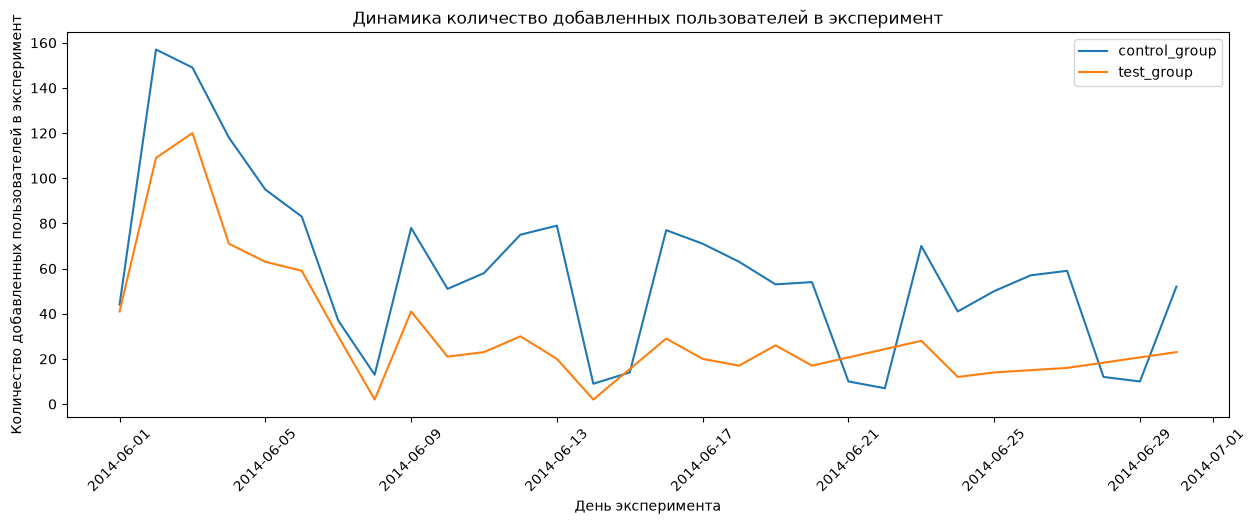

In [115]:
plt.figure(figsize=(15,5))

experiment_groups = filling_dynamics['experiment_group'].unique()

filling_dynamics['day'] = pd.to_datetime(filling_dynamics['day'])


for experiment_group in experiment_groups:
	data = filling_dynamics[filling_dynamics['experiment_group'] == experiment_group]
	plt.plot(data['day'], data['new_users'], label=experiment_group)

plt.title('Динамика количество добавленных пользователей в эксперимент')
plt.xlabel('День эксперимента')
plt.ylabel('Количество добавленных пользователей в эксперимент')
plt.xticks(rotation=45)
plt.legend()
plt.show()

Пользователи добавлялись довольно синхронно.